# Validate gene signature in external study

In [8]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('Seurat')
quiet_library('tidyverse')
quiet_library('data.table')
quiet_library('ggplot2')
quiet_library('Matrix')
quiet_library('dplyr')
quiet_library('viridis')
quiet_library('future.apply')
quiet_library('scran')
quiet_library('SingleCellExperiment')
quiet_library('DESeq2')
quiet_library('GEOquery')
quiet_library('ggpubr')
quiet_library('broom')

In [9]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
npg_color_ext <- colorRampPalette(npg_color)(15)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)

tnfi_colors = c('grey80', '#F59F00', '#840032', 'grey80')
options(repr.plot.width = 6, repr.plot.height = 6)

In [10]:
# define working path
data_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/GSE129705'
meta_path = '/home/workspace/github/ra-longitudinal/metadata'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/figures'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/GSE129705/results'
if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
proj_name = 'ALTRA_AIM3_scRNA_tnfi_validation_'

In [11]:
run_mcnemar_test = function(x){
    cont_counts = x %>%
            pivot_wider(id_cols = aim3_direction, 
                        names_from = tnfi_direction , values_from = n)
    # print(cont_counts)
    test_res = rstatix::mcnemar_test(cont_counts%>%select(-aim3_direction))%>% as_tibble()
    return(test_res)
}

## load data

In [12]:
# load tnfi degs in related to aim3
tnfi_aim3_degs_comparison_sig <- read_csv(file.path(output_path, 'ALTRA_AIM3_scRNA_tnfi_validation_tnfi_responder_AIM3_degs.csv'))%>%
    mutate(direction=factor(direction))

Rows: 1415 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): gene, cell_type, effect, term, sig, aim3_direction, tnfi_direction...
dbl (12): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values_tnfi, esti...
lgl  (1): group

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [13]:
# make the count table 
tnfi_aim3_deg_counts = tnfi_aim3_degs_comparison_sig%>%
    group_by(cell_type, aim3_direction, tnfi_direction)%>%tally()%>% 
    mutate(treatment='TNFi')%>% rename('tnfi_direction'='treatment_direction')
tnfi_aim3_deg_counts%>% head()

cell_type,aim3_direction,treatment_direction,n,treatment
<chr>,<chr>,<chr>,<int>,<chr>
CD27+ effector B cell,aim3_down,tnfi_up,1,TNFi
CM CD4 T cell,aim3_down,tnfi_down,130,TNFi
CM CD4 T cell,aim3_down,tnfi_up,219,TNFi
CM CD4 T cell,aim3_up,tnfi_down,124,TNFi
CM CD4 T cell,aim3_up,tnfi_up,149,TNFi
CM CD8 T cell,aim3_down,tnfi_down,1,TNFi


In [14]:
# load ab treatment degs
abt_aim3_degs = read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/treatment_validation/ALTRA_AIM3_scRNA_validation_ABT_responder_AIM3_degs.csv',
                         show_col_types = FALSE)
abt_aim3_deg_counts <-  abt_aim3_degs %>%group_by(cell_type, aim3_direction, abt_direction)%>%tally()%>% 
    mutate(treatment='ABT')%>% rename('abt_direction'='treatment_direction')
abt_aim3_deg_counts%>% head()

cell_type,aim3_direction,treatment_direction,n,treatment
<chr>,<chr>,<chr>,<int>,<chr>
CM CD4 T cell,aim3_down,abt_down,8,ABT
CM CD4 T cell,aim3_down,abt_up,165,ABT
CM CD4 T cell,aim3_up,abt_down,37,ABT
CM CD4 T cell,aim3_up,abt_up,23,ABT
CM CD8 T cell,aim3_down,abt_down,1,ABT
Core naive B cell,aim3_down,abt_up,3,ABT


### calculate and plot the odds ratio

In [15]:
quiet_library('epitools')

In [16]:
abt_tnfi_aim3_deg_counts <- bind_rows(abt_aim3_deg_counts, tnfi_aim3_deg_counts)%>% 
    mutate(treatment_direction = paste0('treatment_', str_extract(treatment_direction, 'up|down')))
abt_tnfi_aim3_deg_counts%>% head()

cell_type,aim3_direction,treatment_direction,n,treatment
<chr>,<chr>,<chr>,<int>,<chr>
CM CD4 T cell,aim3_down,treatment_down,8,ABT
CM CD4 T cell,aim3_down,treatment_up,165,ABT
CM CD4 T cell,aim3_up,treatment_down,37,ABT
CM CD4 T cell,aim3_up,treatment_up,23,ABT
CM CD8 T cell,aim3_down,treatment_down,1,ABT
Core naive B cell,aim3_down,treatment_up,3,ABT


In [17]:
degs_counts_test = abt_tnfi_aim3_deg_counts %>% ungroup()%>%  filter(cell_type=='CM CD4 T cell'& treatment=='ABT')%>% 
    mutate(aim3_direction= factor(aim3_direction, levels = c('aim3_up', 'aim3_down')),
          treatment_direction= factor(treatment_direction, levels = c('treatment_up', 'treatment_down')))%>% 
    select(-c(cell_type, treatment))
outcome = 'treatment_direction'
exposure = 'aim3_direction'
contingency_table <- degs_counts_test %>%
    pivot_wider(names_from = all_of(outcome),  values_from = 'n', values_fill = 0)  %>%
    column_to_rownames(var = exposure) %>% select(treatment_up, treatment_down) %>%
    as.matrix()
contingency_table
# Compute odds ratio using epitools
or_result <- oddsratio(contingency_table)
# Extract relevant results
or_summary <- data.frame(
    Odds_Ratio = or_result$measure[2, 1],
    Lower_CI = or_result$measure[2, 2],
    Upper_CI = or_result$measure[2, 3],
    p_value = or_result$p.value[2, 1]
)
or_summary

,treatment_up,treatment_down
aim3_down,165,8
aim3_up,23,37


Odds_Ratio,Lower_CI,Upper_CI,p_value
<dbl>,<dbl>,<dbl>,<dbl>
31.90157,13.80269,82.71166,0


In [18]:
# Function to compute odds ratio from a summary tibble
compute_or_from_summary <- function(deg_counts, celltype_sel, treatment_sel, 
                                    exposure = 'aim3_direction', outcome = 'treatment_direction', count='n') {
      # Check if exposure, outcome, and count columns exist
  if (!all(c(exposure, outcome, count) %in% names(deg_counts))) {
    stop("Error: Specified columns not found in the dataset.")
  }
    # filter deg counts
    # celltype_sel = unique(deg_counts%>% pull(cell_type))
    # treatment_sel = unique(deg_counts%>% pull(treatment))
    deg_counts_fl = deg_counts %>% ungroup() %>% 
        mutate(aim3_direction= factor(aim3_direction, levels = c('aim3_up', 'aim3_down')),
              treatment_direction= factor(treatment_direction, levels = c('treatment_up', 'treatment_down')))
  
  # Convert to wide-format contingency table
    outcome_levels = deg_counts_fl%>% pull(outcome)%>% levels()
    contingency_table <- deg_counts_fl %>%
        pivot_wider(names_from = !!sym(outcome), values_from = !!sym(count), values_fill = 0) %>%
        column_to_rownames(var = exposure) %>% select (all_of(outcome_levels)) %>%
        as.matrix()
    print(paste(treatment_sel, celltype_sel))
    print(contingency_table)
  # Ensure the table is 2x2
  if (!all(dim(contingency_table) == c(2, 2))) {
    stop("Error: Contingency table must be 2x2.")
  }
  
  # Compute odds ratio using epitools
  or_result <- oddsratio(contingency_table, method='wald')

  # Extract relevant results
  or_summary <- data.frame(
    Odds_Ratio = or_result$measure[2, 1],
    Lower_CI = or_result$measure[2, 2],
    Upper_CI = or_result$measure[2, 3],
    p_value = or_result$p.value[2, 1]
  ) %>% as_tibble() %>% mutate('cell_type' = !!(celltype_sel), 'treatment'=!!(treatment_sel))

  return(or_summary)
}


In [19]:
(37/8)/(23/165)

[1] 33.17935

In [20]:
cd4cm_or <-  abt_tnfi_aim3_deg_counts%>% filter(cell_type=='CM CD4 T cell' & treatment=='ABT')%>% 
    compute_or_from_summary(celltype_sel='CM CD4 T cell', treatment_sel='ABT',
                            exposure = 'treatment_direction', outcome = 'aim3_direction')
cd4na_or <-  abt_tnfi_aim3_deg_counts%>% filter(cell_type=='Core naive CD4 T cell' & treatment=='ABT')%>% 
    compute_or_from_summary(celltype_sel='Core naive CD4 T cell',
                            treatment_sel='ABT', exposure = 'treatment_direction', outcome = 'aim3_direction')

[1] "ABT CM CD4 T cell"
               aim3_up aim3_down
treatment_down      37         8
treatment_up        23       165
[1] "ABT Core naive CD4 T cell"
               aim3_up aim3_down
treatment_down      40        11
treatment_up        22       164


In [21]:
cd4cm_or
cd4na_or

Odds_Ratio,Lower_CI,Upper_CI,p_value,cell_type,treatment
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
33.17935,13.76295,79.98786,0,CM CD4 T cell,ABT


Odds_Ratio,Lower_CI,Upper_CI,p_value,cell_type,treatment
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
27.10744,12.15513,60.45293,0,Core naive CD4 T cell,ABT


In [22]:
abt_tnfi_aim3_deg_counts %>% filter(cell_type%in% c('CM CD4 T cell', 'Core naive CD4 T cell'))%>% 
    pivot_wider(id_cols = c('treatment','cell_type', 'aim3_direction'),
                names_from = 'treatment_direction', values_from = 'n', values_fill = 0)

treatment,cell_type,aim3_direction,treatment_down,treatment_up
<chr>,<chr>,<chr>,<int>,<int>
ABT,CM CD4 T cell,aim3_down,8,165
ABT,CM CD4 T cell,aim3_up,37,23
ABT,Core naive CD4 T cell,aim3_down,11,164
ABT,Core naive CD4 T cell,aim3_up,40,22
TNFi,CM CD4 T cell,aim3_down,130,219
TNFi,CM CD4 T cell,aim3_up,124,149
TNFi,Core naive CD4 T cell,aim3_down,112,210
TNFi,Core naive CD4 T cell,aim3_up,108,150


In [23]:
# get odds ratio for all cell type 
or_results = abt_tnfi_aim3_deg_counts %>% filter(cell_type%in% c('CM CD4 T cell', 'Core naive CD4 T cell'))%>%
    group_by(cell_type, treatment) %>%
    group_modify(~compute_or_from_summary(.x, celltype_sel=unique(.x$cell_type), treatment_sel=unique(.x$treatment),
                                          exposure = 'treatment_direction', outcome ='aim3_direction' , count='n'))%>% 
    mutate('treament.celltype' = paste(treatment, cell_type, sep=': '))

Warning message:
“Unknown or uninitialised column: `treatment`.”
Warning message:
“Unknown or uninitialised column: `cell_type`.”


character(0)
               aim3_up aim3_down
treatment_down      37         8
treatment_up        23       165


Warning message:
“Unknown or uninitialised column: `treatment`.”
Warning message:
“Unknown or uninitialised column: `cell_type`.”


character(0)
               aim3_up aim3_down
treatment_down     124       130
treatment_up       149       219


Warning message:
“Unknown or uninitialised column: `treatment`.”
Warning message:
“Unknown or uninitialised column: `cell_type`.”


character(0)
               aim3_up aim3_down
treatment_down      40        11
treatment_up        22       164


Warning message:
“Unknown or uninitialised column: `treatment`.”
Warning message:
“Unknown or uninitialised column: `cell_type`.”


character(0)
               aim3_up aim3_down
treatment_down     108       112
treatment_up       150       210


In [24]:
or_results %>% head()

cell_type,treatment,Odds_Ratio,Lower_CI,Upper_CI,p_value,treament.celltype
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CM CD4 T cell,ABT,33.179348,13.7629531,79.987857,0.00000000,ABT: CM CD4 T cell
CM CD4 T cell,TNFi,1.401962,1.0157347,1.935049,0.04037894,TNFi: CM CD4 T cell
Core naive CD4 T cell,ABT,27.107438,12.1551293,60.452931,0.00000000,ABT: Core naive CD4 T cell
Core naive CD4 T cell,TNFi,1.350000,0.9634894,1.891562,0.08212868,TNFi: Core naive CD4 T cell


In [43]:
log2(33)

[1] 5.044394

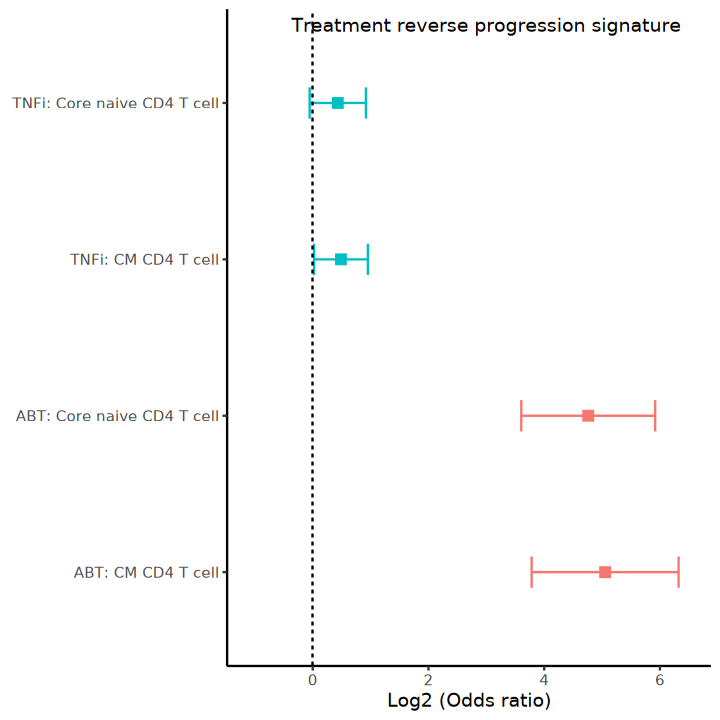

In [42]:
# plot the forest plot 
p1 = ggplot(or_results, aes(x=log2(Odds_Ratio), y=treament.celltype, color=treatment)) + 
    geom_point(aes(x=log2(Odds_Ratio)), shape=15, size=3) +
    geom_errorbar(aes(xmin=log2(Lower_CI), xmax=log2(Upper_CI)),  width = 0.2) + 
    geom_vline(xintercept = 0, linetype="dashed") + 
    annotate("text", x = 3, y = 4.5, label = "Treatment reverse progression signature") +
    theme_classic() + xlab('Log2 (Odds ratio)') + guides(color="none") +ylab('') + xlim(-1.1, 6.5)
p1
ggsave(file.path(fig_path, paste0(proj_name, 'ABT_TNFi_odds_ratio_log2.pdf')),
               width = 4, height = 3)

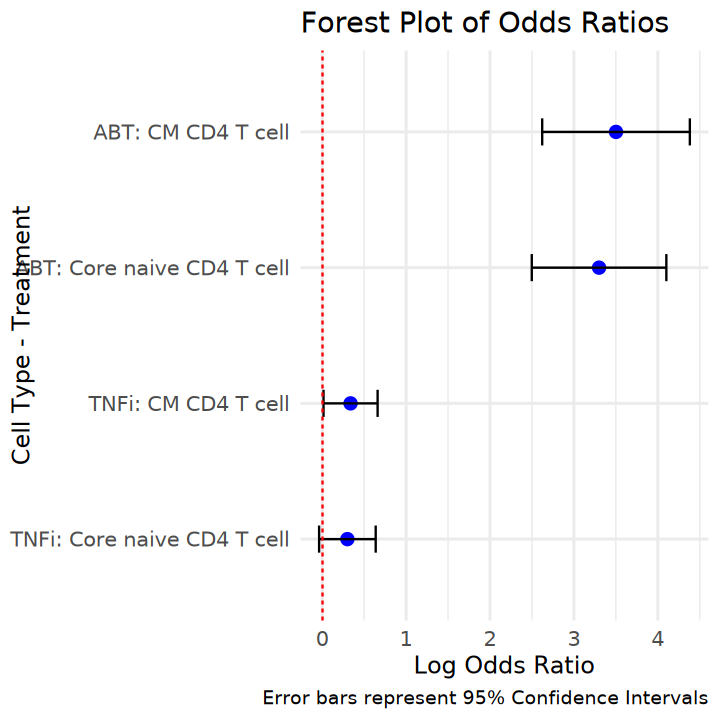

In [43]:
# Ensure the OR results are formatted correctly
or_results_grouped <- or_results %>%
  mutate(
    #cell_treatment = paste(cell_type, treatment, sep = " - "),  # Combine group labels
    log_or = log(Odds_Ratio)  # Log-transform OR for better visualization
  )

# Create the forest plot
forest_plot <- ggplot(or_results_grouped, aes(x = log_or, y = reorder(treament.celltype, log_or))) +
  geom_point(size = 3, color = "blue") +  # Plot points for OR
  geom_errorbarh(aes(xmin = log(Lower_CI), xmax = log(Upper_CI)), height = 0.2, color = "black") +  # CI bars
  geom_vline(xintercept = 0, linetype = "dashed", color = "red") +  # Reference line at OR = 1
  labs(
    title = "Forest Plot of Odds Ratios",
    x = "Log Odds Ratio",
    y = "Cell Type - Treatment",
    caption = "Error bars represent 95% Confidence Intervals"
  ) +
  theme_minimal(base_size = 14) +
  theme(axis.text.y = element_text(size = 12), axis.text.x = element_text(size = 12))
forest_plot

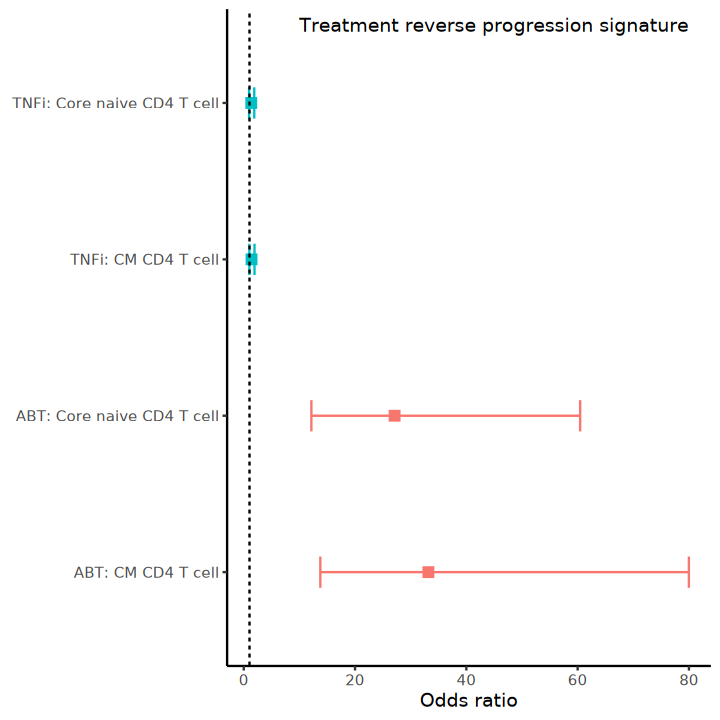

In [44]:
# plot the forest plot 
p1 = ggplot(or_results, aes(x=Odds_Ratio, y=treament.celltype, color=treatment)) + 
    geom_point(aes(x=Odds_Ratio), shape=15, size=3) +
    geom_errorbar(aes(xmin=Lower_CI, xmax=Upper_CI),   width = 0.2) + 
    geom_vline(xintercept = 1, linetype="dashed") +
    annotate("text", x = 45, y = 4.5, label = "Treatment reverse progression signature") +
    theme_classic() + xlab('Odds ratio')+ ylab('') + 
    guides(color="none")
p1
ggsave(file.path(fig_path, paste0(proj_name, 'ABT_TNFi_odds_ratio.png')),
               width = 6, height = 4)

In [45]:
tnfi_aim3_degs_comparison_sig %>% filter(cell_type== 'CM CD4 T cell')%>%
    filter(q_values_tnfi<0.05&q_values_aim3<0.05&(aim3_direction=='aim3_up'&tnfi_direction=='tnfi_down'))

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_tnfi,cell_type,effect,group,⋯,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,tnfi_direction,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<fct>
SMAP2,15227.5786,-0.4531785,0.13426352,-3.375291,7.373767e-04,0.0070574649,CM CD4 T cell,fixed,NA,⋯,0.0003063688,1.237028e-04,2.476652,42.29082,0.0173437372,0.04806505,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
SNX27,1784.7201,-0.2694863,0.11078977,-2.432411,1.499867e-02,0.0496348400,CM CD4 T cell,fixed,NA,⋯,0.0002152061,8.127827e-05,2.647769,46.00000,0.0110609881,0.04306205,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
GATAD2B,1194.6725,-0.2088058,0.07902038,-2.642430,8.231344e-03,0.0337529837,CM CD4 T cell,fixed,NA,⋯,0.0003313373,1.375198e-04,2.409378,45.09841,0.0201235236,0.04997510,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
CACUL1,897.7542,-0.3336427,0.10910032,-3.058128,2.227243e-03,0.0143508074,CM CD4 T cell,fixed,NA,⋯,0.0003170683,1.113439e-04,2.847648,44.98618,0.0066157914,0.03696499,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
PTPRJ,4126.6862,-0.3432988,0.10877096,-3.156162,1.598598e-03,0.0116245715,CM CD4 T cell,fixed,NA,⋯,0.0003876458,1.381110e-04,2.806771,45.42507,0.0073460890,0.03819507,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
MARK2,2373.4092,-0.3745961,0.08493048,-4.410620,1.030749e-05,0.0004424952,CM CD4 T cell,fixed,NA,⋯,0.0003495491,1.006051e-04,3.474468,42.49027,0.0011913614,0.02851903,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
PICALM,3755.1200,-0.3217543,0.12394463,-2.595952,9.432928e-03,0.0370550727,CM CD4 T cell,fixed,NA,⋯,0.0003499683,1.292593e-04,2.707491,45.36699,0.0095248190,0.04249230,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
ETV6,2008.5342,-0.1766131,0.07070534,-2.497875,1.249403e-02,0.0441428525,CM CD4 T cell,fixed,NA,⋯,0.0003439519,1.107517e-04,3.105614,43.81189,0.0033251508,0.03424478,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
CALCOCO1,1973.1290,-0.2187537,0.07134744,-3.066034,2.169188e-03,0.0141819032,CM CD4 T cell,fixed,NA,⋯,0.0003613600,1.392707e-04,2.594660,46.00000,0.0126613880,0.04356779,tnfiSig&Aim3Sig,aim3_up,tnfi_down,Increased during progression to RA& Decreased post tnfi
